In [10]:
# 1.加载数据集
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target
print('data shape:{0};no. positive:{1};no. negative:{2}'.format(X.shape,y[y==1].shape[0],y[y==0].shape[0]))

data shape:(569, 30);no. positive:357;no. negative:212


In [11]:
cancer.data[0]

array([1.799e+01, 1.038e+01, 1.228e+02, 1.001e+03, 1.184e-01, 2.776e-01,
       3.001e-01, 1.471e-01, 2.419e-01, 7.871e-02, 1.095e+00, 9.053e-01,
       8.589e+00, 1.534e+02, 6.399e-03, 4.904e-02, 5.373e-02, 1.587e-02,
       3.003e-02, 6.193e-03, 2.538e+01, 1.733e+01, 1.846e+02, 2.019e+03,
       1.622e-01, 6.656e-01, 7.119e-01, 2.654e-01, 4.601e-01, 1.189e-01])

In [12]:
# 2.模型训练
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

model = LogisticRegression()
model.fit(X_train,y_train)
train_score = model.score(X_train,y_train)
test_score = model.score(X_test,y_test)

print("train_score:{train_score:.6f};test_score:{test_score:.6f}".format(train_score=train_score,test_score=test_score))

train_score:0.960440;test_score:0.929825


/opt/homebrew/Caskroom/miniconda/base/envs/ioe/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [13]:
import numpy as np
y_pred = model.predict(X_test)
print("match:{0}/{1}".format(np.equal(y_pred,y_test).shape[0],y_test.shape[0]))

match:114/114


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression

cancer = load_breast_cancer()
X = cancer.data
y = cancer.target
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

model = LogisticRegression()
model.fit(X_train,y_train)

# 预测概率：找出预测概率低于90%的样本
y_pred_proba = model.predict_proba(X_test) # 计算每个测试样本的预测概率
print('sample of predict probability:{0}'.format(y_pred_proba[0]))
# 找出第一列，即预测为阴性的概率大于0.1的样本，保存在result里
y_pred_proba_0 = y_pred_proba[:,0]>0.1
result = y_pred_proba[y_pred_proba_0]
# 在result里，找出第二列，即预测为阳性的概率大于0.1的样本
y_pred_proba_1 = result[:,1]>0.1
print(y_pred_proba_1)

sample of predict probability:[1.00000000e+00 1.41791165e-17]
[False False False False False False False False False False False False
  True  True False  True False False False False False False False False
 False False False False False False False False False False  True False
 False False  True  True False False False  True False False  True  True
  True False  True]


/opt/homebrew/Caskroom/miniconda/base/envs/ioe/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [18]:
# 3.模型优化
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
import time

cancer = load_breast_cancer()
X = cancer.data
y = cancer.target
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

# 首先，增加多项式预处理
def polynomial_model(degree=1,**kwarg):
    polynomial_features = PolynomialFeatures(degree=degree,include_bias=False)
    logistic_regression = LogisticRegression(**kwarg)
    pipeline = Pipeline([("polynomial_features",polynomial_features),("logistic_regression",logistic_regression)])
    return pipeline

# 接着，增加二阶多项式特征，创建并训练模型
model = polynomial_model(degree=2,penalty='l1',solver='liblinear')
start = time.time()
model.fit(X_train,y_train)
train_score = model.score(X_train,y_train)
cv_score = model.score(X_test,y_test)
print('elaspe:{0:.6f};train_score:{1:.6f};cv_score:{2:.6f}'.format(time.time()-start,train_score,cv_score))

# L1范数作为正则化项可以实现参数的稀疏化，即自动选择出那些对模型有关联的重要特征
# 从而使得模型的评分显著增加，def polynomial_model()背上

# 逻辑回归模型的coef_属性里保存的就是模型参数，增加二阶多项式特征，输入特征由原来的30多个增加到495个，最终大多数都被丢弃，只留下103个有效特征
import numpy as np
logistic_regression = model.named_steps['logistic_regression']
print('model parameters shape:{0};count of non-zero elemet:{1}'.format(logistic_regression.coef_.shape,
                                                                        np.count_nonzero(logistic_regression.coef_)))



elaspe:0.324893;train_score:0.997802;cv_score:0.982456
model parameters shape:(1, 495);count of non-zero elemet:96


In [19]:
! pip install matplotlib

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 11.2 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 10.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [matplotlib]6 [matplotlib]


Matplotlib is building the font cache; this may take a moment.


elaspe:-1764382165.356753;


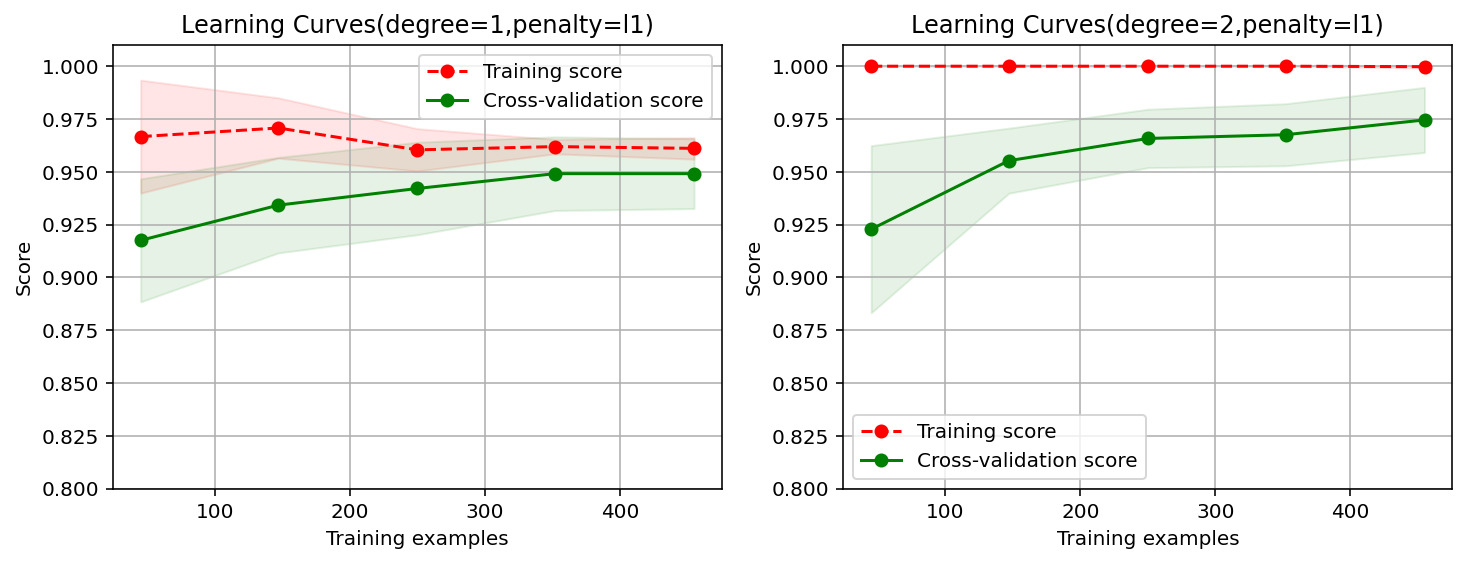

In [20]:
# 4.学习曲线
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
import time
import matplotlib.pyplot as plt
from utils import plot_learning_curve
from sklearn.model_selection import ShuffleSplit


cancer = load_breast_cancer()
X = cancer.data
y = cancer.target
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

# 增加多项式预处理
def polynomial_model(degree=1,**kwarg):
    polynomial_features = PolynomialFeatures(degree=degree,include_bias=False)
    logistic_regression = LogisticRegression(**kwarg)
    pipeline = Pipeline([("polynomial_features",polynomial_features),("logistic_regression",logistic_regression)])
    return pipeline

start = time.time()
cv = ShuffleSplit(n_splits=10,test_size=0.2,random_state=0)
title = 'Learning Curves(degree={0},penalty={1})'
degrees = [1,2]
penalty = 'l1'

plt.figure(figsize=(12,4),dpi=144)
for i in range(len(degrees)):
    plt.subplot(1,len(degrees),i+1)
    plot_learning_curve(plt,polynomial_model(degree=degrees[i],penalty=penalty,solver='liblinear',max_iter=300),
                                                title.format(degrees[i],penalty),X,y,ylim = (0.8,1.01),cv=cv)

print('elaspe:{0:.6f};'.format(time.process_time()-start))
plt.show()


elaspe:32.734703;


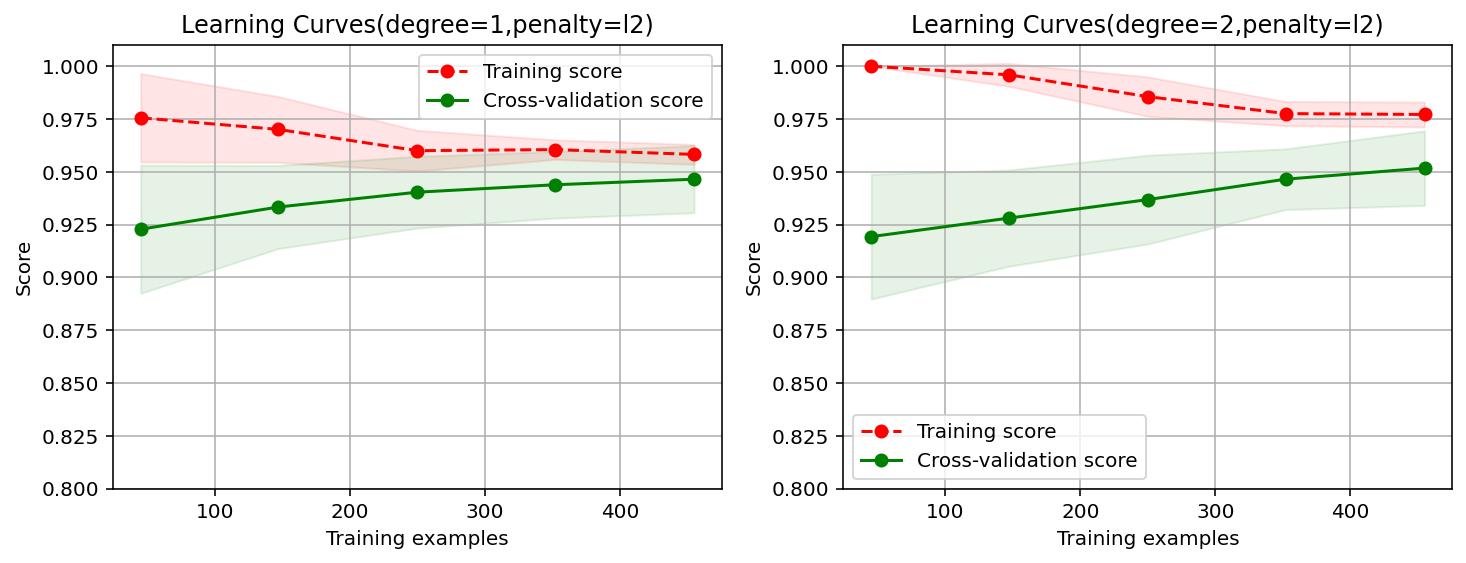

In [21]:
penalty = 'l2'
plt.figure(figsize=(12,4),dpi=144)
for i in range(len(degrees)):
    plt.subplot(1,len(degrees),i+1)
    plot_learning_curve(plt,polynomial_model(degree=degrees[i],penalty=penalty,solver='liblinear',max_iter=300),
                                                title.format(degrees[i],penalty),X,y,ylim = (0.8,1.01),cv=cv)

print('elaspe:{0:.6f};'.format(time.time()-start))
plt.show()